In [138]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score, precision_recall_curve, confusion_matrix
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import numpy as np

## Loading the dataset and doing some exploratory analysis

In [139]:
#loading dataset into a pandas DataFrame
df = pd.read_csv('creditcard.csv')

#relevant information on the data
print(f'Shape: {df.shape} \n')

#0 is legit, 1 is fraud
print(df['Class'].value_counts())
fraud_count = df['Class'].value_counts()[1]
legit_count = df['Class'].value_counts()[0]

print(f'Fraud Percent: {fraud_count/(fraud_count + legit_count)}')
print("\nNull counts:")
print(df.isnull().sum())
df.head()

Shape: (284807, 31) 

Class
0    284315
1       492
Name: count, dtype: int64
Fraud Percent: 0.001727485630620034

Null counts:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## Important Information
There are not many fraud entries in the dataset (around 0.17%), meaning that I will have to ensure:
- testing and training sets each have an adequate number of fraud entries
- the model doesn't default to labeling everything as legit for high accuracy

## Features
Time: Number of seconds elapsed between this transaction and the first transaction in the dataset  
V1 - V28: User features - may be result of a PCA Dimensionality reduction to protect user identities and sensitive  
Amount: Purchase price

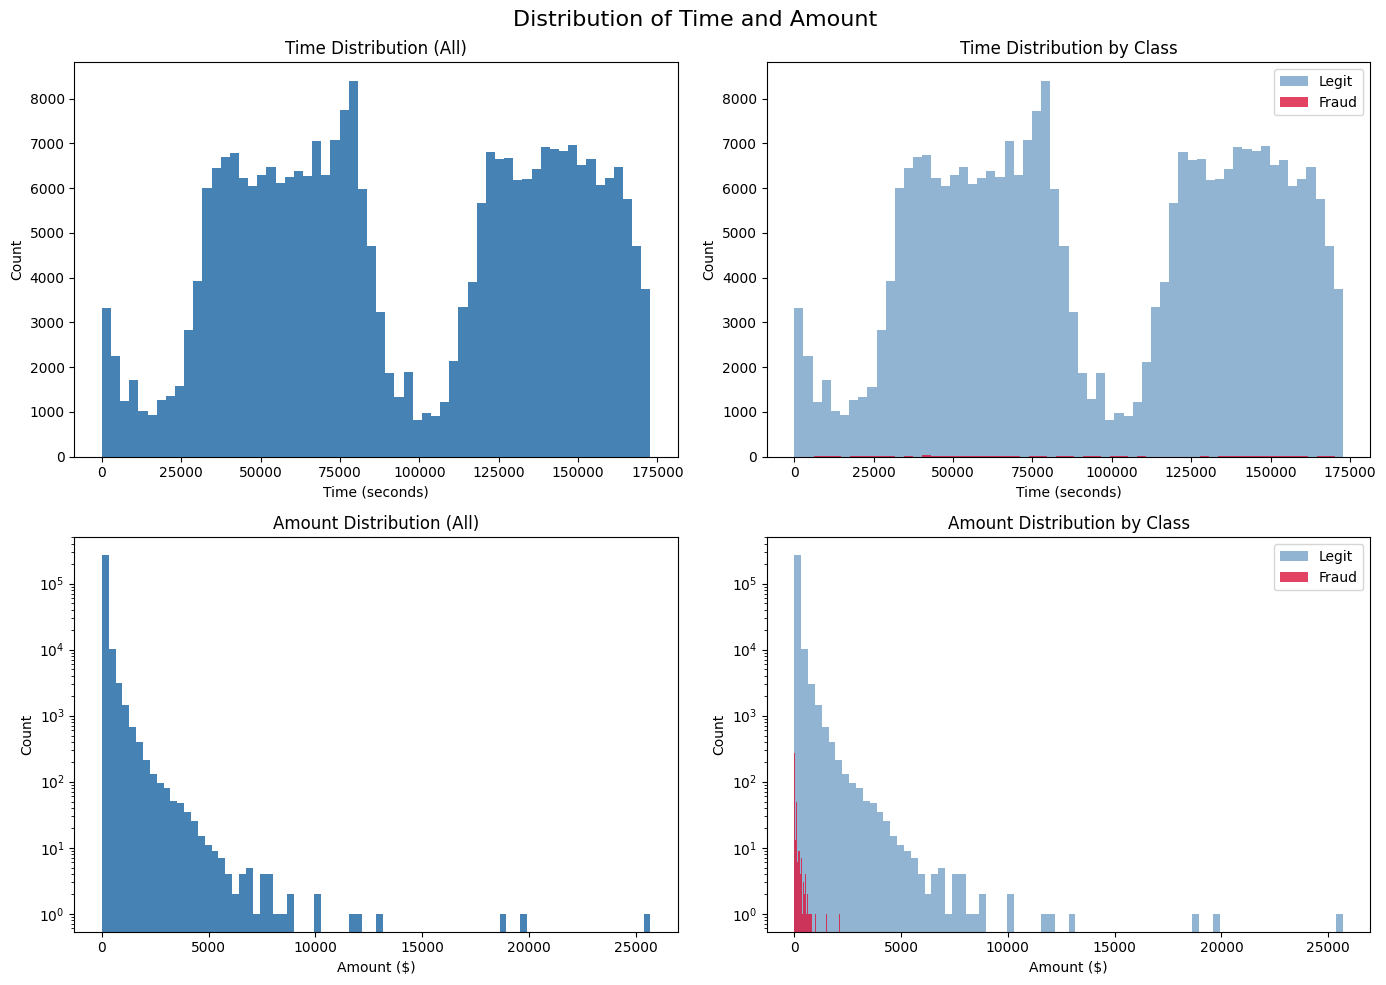

In [140]:
# AI Generated Cell

#creating figure with 4 different graphs
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Distribution of Time and Amount', fontsize=16)

fraud = df[df['Class'] == 1]
legit = df[df['Class'] == 0]

# Time - overall
axes[0, 0].hist(df['Time'], bins=60, color='steelblue', edgecolor='none')
axes[0, 0].set_title('Time Distribution (All)')
axes[0, 0].set_xlabel('Time (seconds)')
axes[0, 0].set_ylabel('Count')

# Time - by class (Legit and Fraud)
axes[0, 1].hist(legit['Time'], bins=60, alpha=0.6, label='Legit', color='steelblue', edgecolor='none')
axes[0, 1].hist(fraud['Time'], bins=60, alpha=0.8, label='Fraud', color='crimson', edgecolor='none')
axes[0, 1].set_title('Time Distribution by Class')
axes[0, 1].set_xlabel('Time (seconds)')
axes[0, 1].set_ylabel('Count')
axes[0, 1].legend()

# Amount - overall (log scale for readability)
axes[1, 0].hist(df['Amount'], bins=80, color='steelblue', edgecolor='none')
axes[1, 0].set_title('Amount Distribution (All)')
axes[1, 0].set_xlabel('Amount ($)')
axes[1, 0].set_ylabel('Count')
axes[1, 0].set_yscale('log')

# Amount - by class
axes[1, 1].hist(legit['Amount'], bins=80, alpha=0.6, label='Legit', color='steelblue', edgecolor='none')
axes[1, 1].hist(fraud['Amount'], bins=80, alpha=0.8, label='Fraud', color='crimson', edgecolor='none')
axes[1, 1].set_title('Amount Distribution by Class')
axes[1, 1].set_xlabel('Amount ($)')
axes[1, 1].set_ylabel('Count')
axes[1, 1].set_yscale('log')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

In [141]:
#Time and Amount values
print(f"Time  — mean: {round(df['Time'].mean(), 0)}s, median: {round(df['Time'].median(), 0)}s")
print(f"Amount — mean: ${round(df['Amount'].mean(), 0)}, median: ${round(df['Amount'].median(), 0)}")
print(f"Fraud Amount — mean: ${round(fraud['Amount'].mean(), 0)}, median: ${round(fraud['Amount'].median(), 0)}")

Time  — mean: 94814.0s, median: 84692.0s
Amount — mean: $88.0, median: $22.0
Fraud Amount — mean: $122.0, median: $9.0


## Interesting notes:
The median fraud purchases are actually much lower than the medain of legit purchases. Yet there seem to be some high outliers that drag the mean higher.
The time also shows that the fraud purchases are evenly spaced out, and don't follow the trend of legit purchases. 

Before going into making a model, I am going to do some data transformations - I will scale time and amount in my dataset to follow the PCA that has already been done on the other features in the dataset. 

In [142]:
#Scaling
scaler = StandardScaler()
df['Amount'] = scaler.fit_transform(df[['Amount']])
df['Time'] = scaler.fit_transform(df[['Time']])

#print(df.value_counts(df['Amount']))
#print(df.value_counts(df['Time']))

X = df.drop('Class', axis=1).values
y = df['Class'].values

#stratify=y is important here so both train and test have enough fraud datapoints to work on
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


# To ensure that the model doesn't label ever entry as legit to achieve high accuracy, I will assign class weights to fraud entries
# If they are missed they will result in higher loss, and better updates with the loss function
#pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
pos_weight = 100
#print(pos_weight)

Here I changed pos_weight to be much lower than what I had it before - I still want fraud cases to have a higher weight connected to them, but I wasn't getting good results when the pos_weight was closer to ~550

## Model Creation

I decided to go with a preceptron for this task, as they are good with tabular data, as well as classification tasks. They are also easy to work with

In [143]:
#3 layer multi-layer perceptron

class FraudMLP(nn.Module):
    def __init__(self, input_dim=30): #we have 30 features - 28 hidden, time, and amount
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.3), #dropout is used to prevent overfitting
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 1), #output a single value
        )

    def forward(self, x):
        return self.net(x)

#hyperparameter
learning_rate = 1e-3

## Convert to tensors

Since I am using pytorch for this, I will have to load the data as tensors

In [144]:
#AI Generated Cell
X_train_t = torch.tensor(X_train, dtype=torch.float32)
X_test_t  = torch.tensor(X_test,  dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
y_test_t  = torch.tensor(y_test,  dtype=torch.float32).unsqueeze(1)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=256, shuffle=True)
test_loader  = DataLoader(TensorDataset(X_test_t,  y_test_t),  batch_size=256)

## loss function and optimizer

BCEWithLogitsLoss is more numerically stable than BCELoss with Sigmoid  
(AI helped with this decision)

In [145]:
model = FraudMLP(input_dim=X_train.shape[1])

criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pos_weight], dtype=torch.float32))
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
#scheduler to decrease the learning rate in deeper epochs
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

## Training loop

Each epoch: 
- forward pass
- compute loss 
- backpropagate gradients 
- update weights

In [146]:
#hyperparameter
EPOCHS = 60

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad() #clearing gradients from past run through
        logits = model(X_batch) #get predictions (the forward pass)
        loss = criterion(logits, y_batch) #measuring loss
        loss.backward() #computing gradients
        optimizer.step() #update weights
        running_loss += loss.item() #measure loss (for output)
    
    #using scheduler to update learning rate
    avg_loss = running_loss / len(train_loader)
    scheduler.step(avg_loss)

    #output the results while running
    if (epoch + 1) % 10 == 0:
        avg_loss = running_loss / len(train_loader)
        print(f"Epoch {epoch+1:>3}/{EPOCHS}  loss: {avg_loss:.4f}")

Epoch  10/60  loss: 0.0597
Epoch  20/60  loss: 0.0444
Epoch  30/60  loss: 0.0338
Epoch  40/60  loss: 0.0294
Epoch  50/60  loss: 0.0210
Epoch  60/60  loss: 0.0120


## Evaluation

Using precision, recall, F1, and ROC-AUC instead of accuracy.

In [147]:
model.eval()
with torch.no_grad():
    logits = model(X_test_t)
    probs  = torch.sigmoid(logits).squeeze().numpy()
    preds  = (probs >= 0.5).astype(int)

print(classification_report(y_test, preds, target_names=['Legit', 'Fraud']))
print(f"ROC-AUC: {roc_auc_score(y_test, probs):.4f}")
print(f"Accuracy: {accuracy_score(y_test, preds):.4f}")

              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56864
       Fraud       0.56      0.86      0.68        98

    accuracy                           1.00     56962
   macro avg       0.78      0.93      0.84     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC: 0.9775
Accuracy: 0.9986


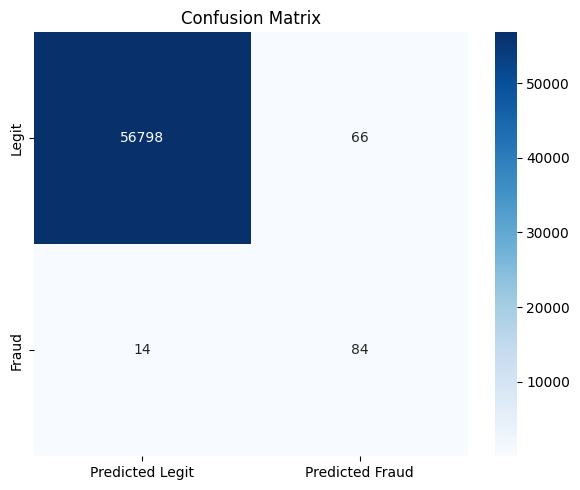

In [148]:
#AI Generated Cell
cm = confusion_matrix(y_test, preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Legit', 'Predicted Fraud'],
            yticklabels=['Legit', 'Fraud'])
plt.title(f'Confusion Matrix')
plt.tight_layout()
plt.show()

## Batch Normalization

Adding BatchNorm1d after each linear layer - normalizes the activations within each batch, leading to faster convergence

In [149]:
#Same model as before with changes stated above
class FraudMLP_v2(nn.Module):
    def __init__(self, input_dim=30):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        return self.net(x)

model_v2    = FraudMLP_v2(input_dim=X_train.shape[1])
criterion_v2 = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pos_weight], dtype=torch.float32))
optimizer_v2 = torch.optim.Adam(model_v2.parameters(), lr=learning_rate)
scheduler_v2 = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_v2, mode='min', factor=0.5, patience=5)

EPOCHS_V2 = 60

for epoch in range(EPOCHS_V2):
    model_v2.train()
    running_loss = 0.0
    for X_batch, y_batch in train_loader:
        optimizer_v2.zero_grad()
        loss = criterion_v2(model_v2(X_batch), y_batch)
        loss.backward()
        optimizer_v2.step()
        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    scheduler_v2.step(avg_loss)
        
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:>3}/{EPOCHS_V2}  loss: {running_loss/len(train_loader):.4f}")

Epoch  10/60  loss: 0.0747
Epoch  20/60  loss: 0.0498
Epoch  30/60  loss: 0.0438
Epoch  40/60  loss: 0.0419
Epoch  50/60  loss: 0.0360
Epoch  60/60  loss: 0.0293


## Threshold Tuning

The default threshold of 0.5 can be an issue since of the data imbalance - plotting precision-recall to see the trade-off  
Picking the threshold that maximises F1

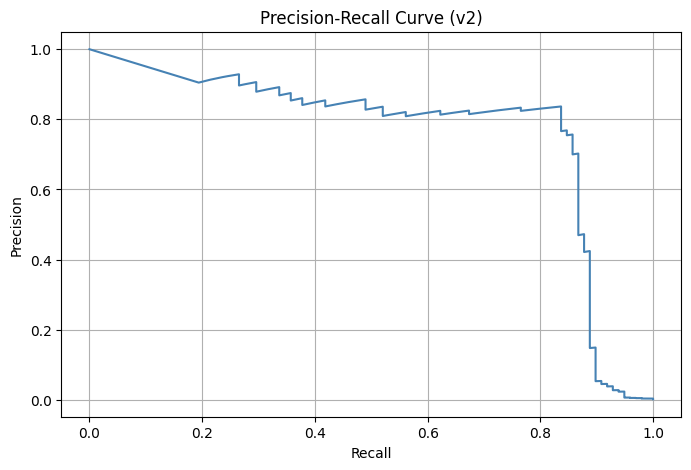

Best threshold: 0.9938  (F1=0.8367)


In [150]:
#AI Generated Cell

model_v2.eval()
with torch.no_grad():
    logits_v2 = model_v2(X_test_t)
    probs_v2  = torch.sigmoid(logits_v2).squeeze().numpy()

# Plot precision-recall curve
precision_vals, recall_vals, thresholds = precision_recall_curve(y_test, probs_v2)

plt.figure(figsize=(8, 5))
plt.plot(recall_vals, precision_vals, color='steelblue')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (v2)')
plt.grid(True)
plt.show()

# Find threshold that maximises fraud F1
f1_scores = 2 * (precision_vals[:-1] * recall_vals[:-1]) / (precision_vals[:-1] + recall_vals[:-1] + 1e-8)
best_threshold_id = np.argmax(f1_scores)
best_threshold = thresholds[best_threshold_id]
print(f"Best threshold: {best_threshold:.4f}  (F1={f1_scores[best_threshold_id]:.4f})")

In [151]:
# Evaluate at best threshold
preds_v2 = (probs_v2 >= best_threshold).astype(int)
print(classification_report(y_test, preds_v2, target_names=['Legit', 'Fraud']))
print(f"ROC-AUC:  {roc_auc_score(y_test, probs_v2):.4f}")
print(f"Accuracy: {accuracy_score(y_test, preds_v2):.4f}")

              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56864
       Fraud       0.84      0.84      0.84        98

    accuracy                           1.00     56962
   macro avg       0.92      0.92      0.92     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC:  0.9787
Accuracy: 0.9994


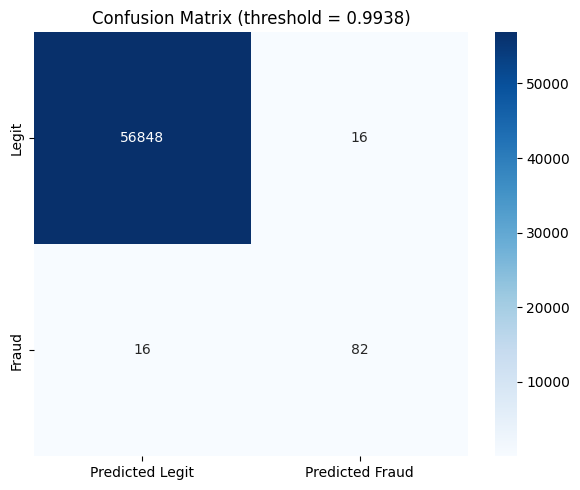

In [152]:
#AI Generated Cell
cm = confusion_matrix(y_test, preds_v2)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Legit', 'Predicted Fraud'],
            yticklabels=['Legit', 'Fraud'])
plt.title(f'Confusion Matrix (threshold = {best_threshold:.4f})')
plt.tight_layout()
plt.show()